In [1]:
!pip install -q torch torchvision torchaudio torchmetrics facenet-pytorch kaggle matplotlib pillow numpy tqdm
!pip install -q torch-fidelity

In [2]:
import os
import math
import random
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, utils

from facenet_pytorch import MTCNN
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
ROOT = Path("./data")
CELEBA_ROOT = ROOT / "celeba"
RAW_IMG_DIR = CELEBA_ROOT / "img_align_celeba" / "img_align_celeba"
CROPPED_DIR = ROOT / "celeba_faces_cropped"
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True, parents=True)

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 256
BASE_CH = 128

EPOCHS_GAN = 20
EPOCHS_CGAN = 20
EPOCHS_WGAN = 20

LR_G = 2e-4
LR_D = 2e-4
BETA1 = 0.5
BETA2 = 0.999
NUM_WORKERS = 0
MAX_PREPROCESS = 60000
TRAIN_LIMIT = 50000
VAL_LIMIT = 5000
TEST_LIMIT = MAX_PREPROCESS - TRAIN_LIMIT - VAL_LIMIT
assert TEST_LIMIT > 0
ATTR_NAME = "Male"

In [5]:
attr_df = pd.read_csv(CELEBA_ROOT / "list_attr_celeba.csv")
partition_df = pd.read_csv(CELEBA_ROOT / "list_eval_partition.csv")

attr_df["image_id"] = attr_df["image_id"].astype(str)
partition_df["image_id"] = partition_df["image_id"].astype(str)

meta_df = attr_df.merge(partition_df, on="image_id", how="inner")
meta_df[ATTR_NAME] = (meta_df[ATTR_NAME] == 1).astype(int)

print(meta_df.head())
print(meta_df["partition"].value_counts())
print(meta_df[ATTR_NAME].value_counts())

     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Smiling  Straight_Hair  \
0    -1     -1        -1        -1          -1  ...        1              1   
1    -1     -1        -1         1          -1  ...        1             -1   
2    -1     -1         1        -1          -1  ...       -1             -1   
3    -1     -1        -1        -1          -1  ...       -1              1   
4    -1     -1         1        -1          -1  ...       -1             -1   

   Wavy_Hair  Wearing_Earrings  Wearin

In [6]:
CROPPED_DIR.mkdir(exist_ok=True, parents=True)

mtcnn = MTCNN(
    image_size=IMAGE_SIZE,
    margin=14,
    keep_all=False,
    post_process=False,
    device=device
)

In [7]:
if MAX_PREPROCESS is None:
    selected_meta_df = meta_df.copy()
else:
    split_limits = {0: TRAIN_LIMIT, 1: VAL_LIMIT, 2: TEST_LIMIT}
    selected_parts = []
    for partition, limit in split_limits.items():
        part_df = meta_df[meta_df["partition"] == partition].head(limit)
        if len(part_df) < limit:
            raise ValueError(f"Not enough images in partition {partition}: requested {limit}, found {len(part_df)}")
        selected_parts.append(part_df)
    selected_meta_df = pd.concat(selected_parts, ignore_index=True)

all_files = [RAW_IMG_DIR / image_id for image_id in selected_meta_df["image_id"]]
missing_files = [p.name for p in all_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing raw images, first 5: {missing_files[:5]}")

print(selected_meta_df["partition"].value_counts().sort_index())
len(all_files)

partition
0    50000
1     5000
2     5000
Name: count, dtype: int64


60000

In [8]:
saved = 0
skipped = 0

for img_path in tqdm(all_files):
    out_path = CROPPED_DIR / img_path.name

    if out_path.exists():
        saved += 1
        continue

    try:
        img = Image.open(img_path).convert("RGB")
        face = mtcnn(img)

        if face is None:
            skipped += 1
            continue

        face = face.permute(1, 2, 0).cpu().numpy()
        face = np.clip(face, 0, 255).astype(np.uint8)
        face = Image.fromarray(face)
        face.save(out_path)

        saved += 1
    except Exception:
        skipped += 1

print("saved:", saved, "skipped:", skipped)

  0%|          | 0/60000 [00:00<?, ?it/s]

saved: 59901 skipped: 99


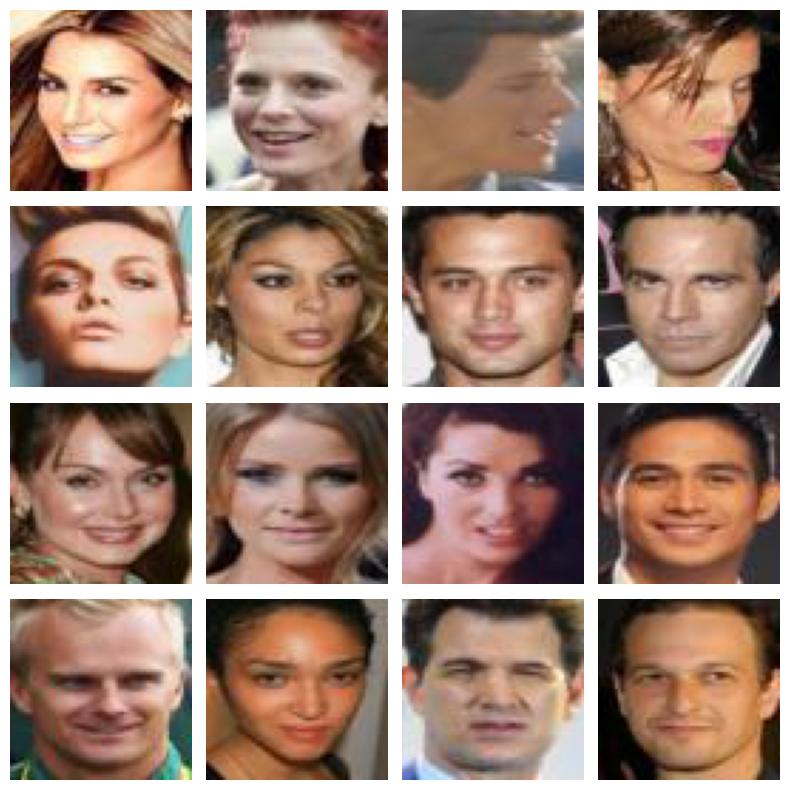

In [9]:
sample_paths = sorted(list(CROPPED_DIR.iterdir()))[:16]
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, p in zip(axes.flatten(), sample_paths):
    img = Image.open(p).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
class CroppedCelebADataset(Dataset):
    def __init__(self, meta_df, cropped_dir, split="train", attr_name="Male", image_size=64, limit=None):
        self.cropped_dir = Path(cropped_dir)
        self.attr_name = attr_name

        split_map = {
            "train": 0,
            "valid": 1,
            "test": 2
        }

        df = meta_df[meta_df["partition"] == split_map[split]].copy()

        items = []
        for _, row in df.iterrows():
            img_path = self.cropped_dir / row["image_id"]
            if img_path.exists():
                label = int(row[attr_name])
                items.append((img_path, label))

        if limit is not None:
            items = items[:limit]

        self.items = items

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [11]:
train_ds = CroppedCelebADataset(
    meta_df=selected_meta_df,
    cropped_dir=CROPPED_DIR,
    split="train",
    attr_name=ATTR_NAME,
    image_size=IMAGE_SIZE,
    limit=TRAIN_LIMIT
)

val_ds = CroppedCelebADataset(
    meta_df=selected_meta_df,
    cropped_dir=CROPPED_DIR,
    split="valid",
    attr_name=ATTR_NAME,
    image_size=IMAGE_SIZE,
    limit=VAL_LIMIT
)

test_ds = CroppedCelebADataset(
    meta_df=selected_meta_df,
    cropped_dir=CROPPED_DIR,
    split="test",
    attr_name=ATTR_NAME,
    image_size=IMAGE_SIZE,
    limit=TEST_LIMIT
)

len(train_ds), len(val_ds), len(test_ds)

(49913, 4990, 4998)

In [12]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

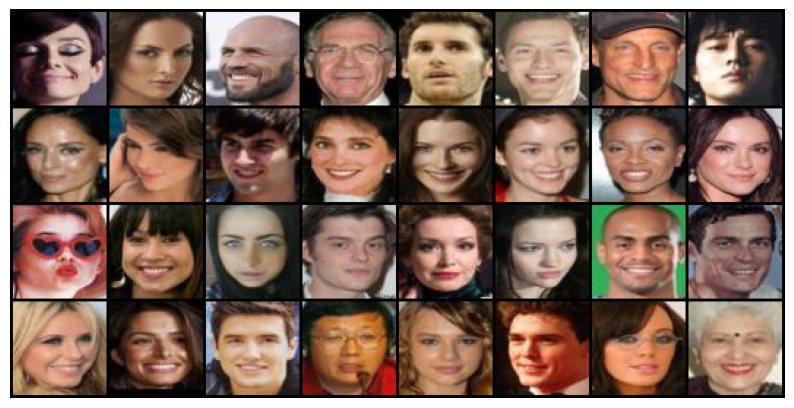

[0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0]


In [13]:
imgs, labels = next(iter(train_loader))
grid = utils.make_grid(imgs[:32], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

print(labels[:16].tolist())

In [14]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, base_ch=64, num_classes=0, embed_dim=32):
        super().__init__()
        self.num_classes = num_classes
        input_dim = z_dim

        if num_classes > 0:
            self.embed = nn.Embedding(num_classes, embed_dim)
            input_dim += embed_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(input_dim, base_ch * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, y=None):
        if self.num_classes > 0:
            y_emb = self.embed(y)
            z = torch.cat([z, y_emb], dim=1)
        x = z.unsqueeze(-1).unsqueeze(-1)
        return self.net(x)

In [15]:
class Discriminator(nn.Module):
    def __init__(self, base_ch=64, num_classes=0, image_size=64):
        super().__init__()
        self.num_classes = num_classes

        if num_classes > 0:
            self.embed = nn.Embedding(num_classes, image_size * image_size)

        in_ch = 3 + (1 if num_classes > 0 else 0)

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 2, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 4, base_ch * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x, y=None):
        if self.num_classes > 0:
            y_map = self.embed(y).view(y.size(0), 1, x.size(2), x.size(3))
            x = torch.cat([x, y_map], dim=1)
        out = self.net(x)
        return out.view(-1)

In [16]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [17]:
def sample_noise(batch_size, z_dim, device):
    return torch.randn(batch_size, z_dim, device=device)

In [18]:
def show_generated_images(generator, z_dim=128, n=32, y=None, title=None):
    generator.eval()
    with torch.no_grad():
        z = sample_noise(n, z_dim, device)
        if y is not None:
            y = y.to(device)
            fake = generator(z, y)
        else:
            fake = generator(z)
    grid = utils.make_grid(fake, nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 10))
    if title is not None:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.show()
    generator.train()

In [19]:
def plot_history(history, title="history"):
    plt.figure(figsize=(8, 4))
    for k, v in history.items():
        plt.plot(v, label=k)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
def train_gan(generator, discriminator, train_loader, epochs, z_dim, lr_g, lr_d, save_name):
    criterion = nn.BCEWithLogitsLoss()

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(BETA1, BETA2))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(BETA1, BETA2))

    history = {"g_loss": [], "d_loss": []}

    fixed_z = sample_noise(32, z_dim, device)

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0

        for real, _ in tqdm(train_loader, desc=f"GAN epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            bsz = real.size(0)

            real_targets = torch.ones(bsz, device=device)
            fake_targets = torch.zeros(bsz, device=device)

            opt_d.zero_grad()

            real_logits = discriminator(real)
            d_real_loss = criterion(real_logits, real_targets)

            z = sample_noise(bsz, z_dim, device)
            fake = generator(z).detach()
            fake_logits = discriminator(fake)
            d_fake_loss = criterion(fake_logits, fake_targets)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad()

            z = sample_noise(bsz, z_dim, device)
            fake = generator(z)
            fake_logits = discriminator(fake)
            g_loss = criterion(fake_logits, real_targets)

            g_loss.backward()
            opt_g.step()

            g_running += g_loss.item()
            d_running += d_loss.item()

        history["g_loss"].append(g_running / len(train_loader))
        history["d_loss"].append(d_running / len(train_loader))

        print(f"epoch {epoch+1}: g_loss={history['g_loss'][-1]:.4f}, d_loss={history['d_loss'][-1]:.4f}")

        generator.eval()
        with torch.no_grad():
            fake = generator(fixed_z)
        grid = utils.make_grid(fake, nrow=8, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis("off")
        plt.show()
        generator.train()

        torch.save({
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "history": history
        }, CHECKPOINT_DIR / save_name)

    return history

In [ ]:
G = Generator(z_dim=LATENT_DIM, base_ch=BASE_CH, num_classes=0).to(device)
D = Discriminator(base_ch=BASE_CH, num_classes=0, image_size=IMAGE_SIZE).to(device)
G.apply(weights_init)
D.apply(weights_init)

gan_history = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    epochs=EPOCHS_GAN,
    z_dim=LATENT_DIM,
    lr_g=LR_G,
    lr_d=LR_D,
    save_name="gan.pt"
)

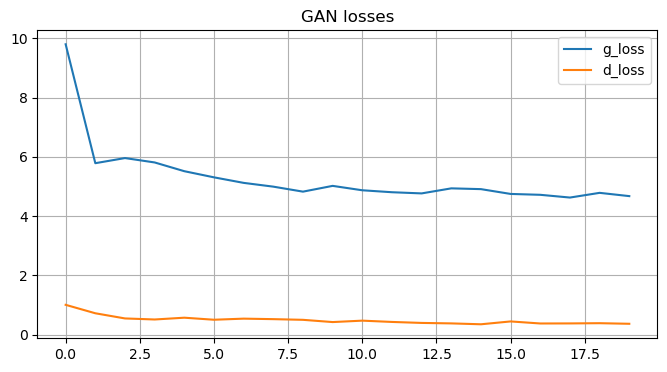

In [22]:
plot_history(gan_history, title="GAN losses")

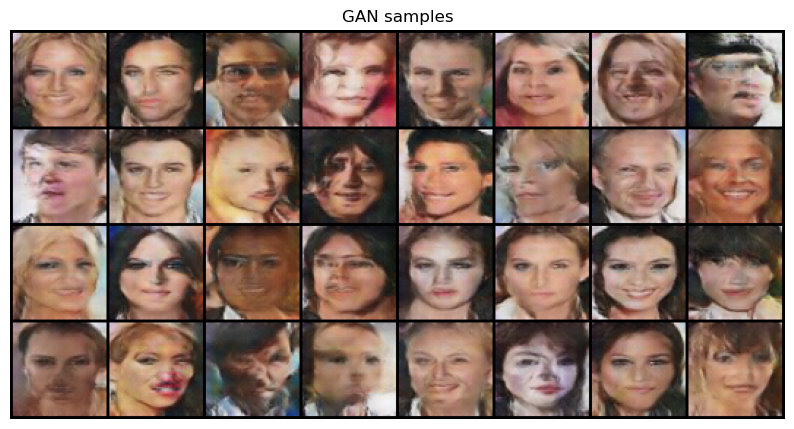

In [23]:
show_generated_images(G, z_dim=LATENT_DIM, n=32, title="GAN samples")

In [24]:
def train_cgan(generator, discriminator, train_loader, epochs, z_dim, lr_g, lr_d, save_name):
    criterion = nn.BCEWithLogitsLoss()

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(BETA1, BETA2))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(BETA1, BETA2))

    history = {"g_loss": [], "d_loss": []}

    fixed_z = sample_noise(16, z_dim, device)
    fixed_y0 = torch.zeros(16, dtype=torch.long, device=device)
    fixed_y1 = torch.ones(16, dtype=torch.long, device=device)

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0

        for real, y in tqdm(train_loader, desc=f"cGAN epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            y = y.to(device)
            bsz = real.size(0)

            real_targets = torch.ones(bsz, device=device)
            fake_targets = torch.zeros(bsz, device=device)

            opt_d.zero_grad()

            real_logits = discriminator(real, y)
            d_real_loss = criterion(real_logits, real_targets)

            z = sample_noise(bsz, z_dim, device)
            fake = generator(z, y).detach()
            fake_logits = discriminator(fake, y)
            d_fake_loss = criterion(fake_logits, fake_targets)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad()

            z = sample_noise(bsz, z_dim, device)
            fake = generator(z, y)
            fake_logits = discriminator(fake, y)
            g_loss = criterion(fake_logits, real_targets)

            g_loss.backward()
            opt_g.step()

            g_running += g_loss.item()
            d_running += d_loss.item()

        history["g_loss"].append(g_running / len(train_loader))
        history["d_loss"].append(d_running / len(train_loader))

        print(f"epoch {epoch+1}: g_loss={history['g_loss'][-1]:.4f}, d_loss={history['d_loss'][-1]:.4f}")

        generator.eval()
        with torch.no_grad():
            fake0 = generator(fixed_z, fixed_y0)
            fake1 = generator(fixed_z, fixed_y1)
        grid0 = utils.make_grid(fake0, nrow=4, normalize=True, value_range=(-1, 1))
        grid1 = utils.make_grid(fake1, nrow=4, normalize=True, value_range=(-1, 1))

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(grid0.permute(1, 2, 0).cpu())
        axes[0].set_title("label 0")
        axes[0].axis("off")
        axes[1].imshow(grid1.permute(1, 2, 0).cpu())
        axes[1].set_title("label 1")
        axes[1].axis("off")
        plt.show()
        generator.train()

        torch.save({
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "history": history
        }, CHECKPOINT_DIR / save_name)

    return history

In [ ]:
cG = Generator(z_dim=LATENT_DIM, base_ch=BASE_CH, num_classes=2).to(device)
cD = Discriminator(base_ch=BASE_CH, num_classes=2, image_size=IMAGE_SIZE).to(device)
cG.apply(weights_init)
cD.apply(weights_init)

cgan_history = train_cgan(
    generator=cG,
    discriminator=cD,
    train_loader=train_loader,
    epochs=EPOCHS_CGAN,
    z_dim=LATENT_DIM,
    lr_g=LR_G,
    lr_d=LR_D,
    save_name="cgan.pt"
)

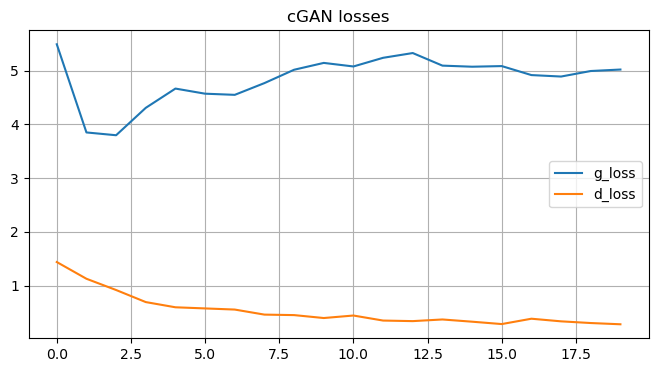

In [26]:
plot_history(cgan_history, title="cGAN losses")

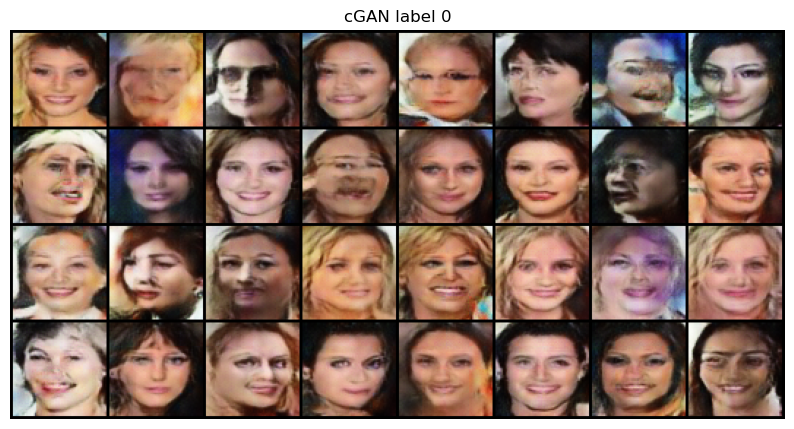

In [27]:
show_generated_images(cG, z_dim=LATENT_DIM, n=32, y=torch.zeros(32, dtype=torch.long), title="cGAN label 0")

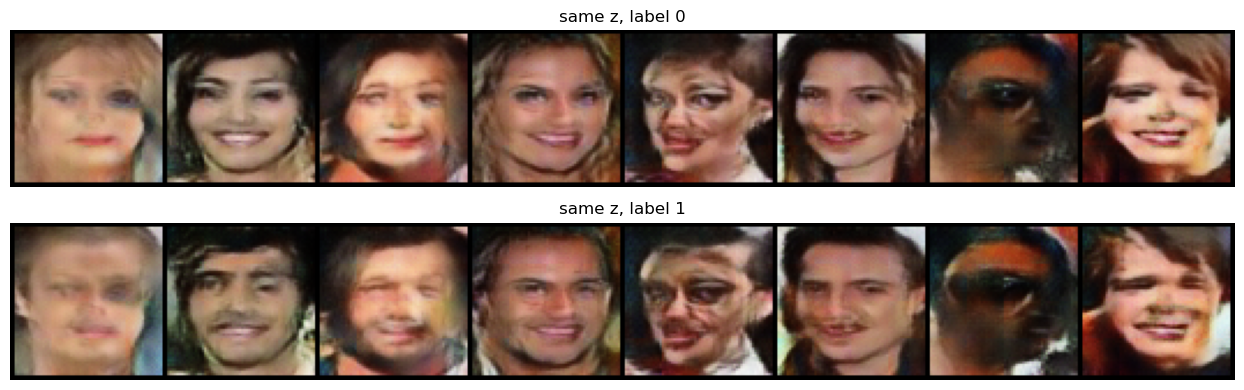

In [28]:
cG.eval()

n = 8
z = sample_noise(n, LATENT_DIM, device)
y0 = torch.zeros(n, dtype=torch.long, device=device)
y1 = torch.ones(n, dtype=torch.long, device=device)

with torch.no_grad():
    img0 = cG(z, y0)
    img1 = cG(z, y1)

grid0 = utils.make_grid(img0, nrow=n, normalize=True, value_range=(-1, 1))
grid1 = utils.make_grid(img1, nrow=n, normalize=True, value_range=(-1, 1))

fig, axes = plt.subplots(2, 1, figsize=(16, 4))
axes[0].imshow(grid0.permute(1, 2, 0).cpu())
axes[0].set_title("same z, label 0")
axes[0].axis("off")

axes[1].imshow(grid1.permute(1, 2, 0).cpu())
axes[1].set_title("same z, label 1")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [29]:
def denorm_to_01(x):
    return ((x.clamp(-1, 1) + 1) / 2).clamp(0, 1)

In [30]:
def resize_for_metrics(x):
    return F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)

In [31]:
@torch.no_grad()
def evaluate_fid_is(generator, real_loader, z_dim=128, conditional=False, max_real=5000, max_fake=5000):
    generator.eval()

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    ins = InceptionScore(normalize=True).to(device)

    real_seen = 0
    fake_seen = 0

    for real, y in tqdm(real_loader, desc="metrics"):
        real = real.to(device)
        y = y.to(device)
        bsz = real.size(0)

        real_01 = denorm_to_01(real)
        real_299 = resize_for_metrics(real_01)
        fid.update(real_299, real=True)
        real_seen += bsz

        z = sample_noise(bsz, z_dim, device)
        if conditional:
            fake = generator(z, y)
        else:
            fake = generator(z)

        fake_01 = denorm_to_01(fake)
        fake_299 = resize_for_metrics(fake_01)
        fid.update(fake_299, real=False)
        ins.update(fake_299)
        fake_seen += bsz

        if real_seen >= max_real or fake_seen >= max_fake:
            break

    fid_value = fid.compute().item()
    is_mean, is_std = ins.compute()

    return fid_value, is_mean.item(), is_std.item()

In [32]:
!pip install -q torch-fidelity

In [33]:
fid_gan, is_gan_mean, is_gan_std = evaluate_fid_is(G, test_loader, z_dim=LATENT_DIM, conditional=False)
print("GAN FID:", fid_gan)
print("GAN IS:", is_gan_mean, "+/-", is_gan_std)

c:\Users\artem\miniconda3\envs\lab1\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


metrics:   0%|          | 0/79 [00:00<?, ?it/s]

GAN FID: 40.06559371948242
GAN IS: 2.174988269805908 +/- 0.06301721930503845


In [34]:
fid_cgan, is_cgan_mean, is_cgan_std = evaluate_fid_is(cG, test_loader, z_dim=LATENT_DIM, conditional=True)
print("cGAN FID:", fid_cgan)
print("cGAN IS:", is_cgan_mean, "+/-", is_cgan_std)

metrics:   0%|          | 0/79 [00:00<?, ?it/s]

cGAN FID: 48.77960205078125
cGAN IS: 2.0586345195770264 +/- 0.05335013568401337


In [35]:
class Critic(nn.Module):
    def __init__(self, base_ch=64, num_classes=0, image_size=64):
        super().__init__()
        self.num_classes = num_classes

        if num_classes > 0:
            self.embed = nn.Embedding(num_classes, image_size * image_size)

        in_ch = 3 + (1 if num_classes > 0 else 0)

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 2, base_ch * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 4, base_ch * 8, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 8, 1, 4, 1, 0)
        )

    def forward(self, x, y=None):
        if self.num_classes > 0:
            y_map = self.embed(y).view(y.size(0), 1, x.size(2), x.size(3))
            x = torch.cat([x, y_map], dim=1)
        return self.net(x).view(-1)

In [36]:
def gradient_penalty(critic, real, fake, y=None):
    bsz = real.size(0)
    alpha = torch.rand(bsz, 1, 1, 1, device=device)
    interpolated = alpha * real + (1 - alpha) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated, y)

    grad = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad = grad.view(grad.size(0), -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [37]:
def train_wgan_gp(generator, critic, train_loader, epochs, z_dim, save_name, conditional=False, n_critic=5, lambda_gp=10.0):
    opt_g = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

    history = {"g_loss": [], "c_loss": []}

    for epoch in range(epochs):
        g_running = 0.0
        c_running = 0.0

        for real, y in tqdm(train_loader, desc=f"WGAN-GP epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            y = y.to(device)
            bsz = real.size(0)

            for _ in range(n_critic):
                z = sample_noise(bsz, z_dim, device)
                if conditional:
                    fake = generator(z, y)
                    c_real = critic(real, y).mean()
                    c_fake = critic(fake.detach(), y).mean()
                    gp = gradient_penalty(critic, real, fake.detach(), y)
                else:
                    fake = generator(z)
                    c_real = critic(real).mean()
                    c_fake = critic(fake.detach()).mean()
                    gp = gradient_penalty(critic, real, fake.detach(), None)

                c_loss = -(c_real - c_fake) + lambda_gp * gp

                opt_c.zero_grad()
                c_loss.backward()
                opt_c.step()

            z = sample_noise(bsz, z_dim, device)
            if conditional:
                fake = generator(z, y)
                g_loss = -critic(fake, y).mean()
            else:
                fake = generator(z)
                g_loss = -critic(fake).mean()

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            g_running += g_loss.item()
            c_running += c_loss.item()

        history["g_loss"].append(g_running / len(train_loader))
        history["c_loss"].append(c_running / len(train_loader))

        print(f"epoch {epoch+1}: g_loss={history['g_loss'][-1]:.4f}, c_loss={history['c_loss'][-1]:.4f}")

        show_generated_images(generator, z_dim=z_dim, n=32, title=f"WGAN-GP epoch {epoch+1}")

        torch.save({
            "generator": generator.state_dict(),
            "critic": critic.state_dict(),
            "history": history
        }, CHECKPOINT_DIR / save_name)

    return history

In [ ]:
wG = Generator(z_dim=LATENT_DIM, base_ch=BASE_CH, num_classes=0).to(device)
wC = Critic(base_ch=BASE_CH, num_classes=0, image_size=IMAGE_SIZE).to(device)
wG.apply(weights_init)

wgan_history = train_wgan_gp(
    generator=wG,
    critic=wC,
    train_loader=train_loader,
    epochs=EPOCHS_WGAN,
    z_dim=LATENT_DIM,
    save_name="wgan_gp.pt",
    conditional=False,
    n_critic=5,
    lambda_gp=10.0
)

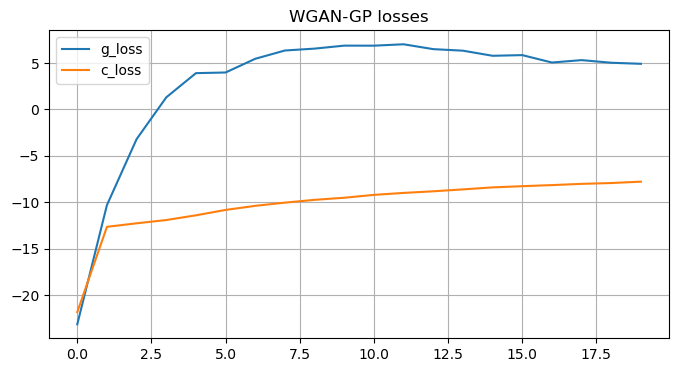

In [39]:
plot_history(wgan_history, title="WGAN-GP losses")

In [40]:
fid_wgan, is_wgan_mean, is_wgan_std = evaluate_fid_is(wG, test_loader, z_dim=LATENT_DIM, conditional=False)
print("WGAN-GP FID:", fid_wgan)
print("WGAN-GP IS:", is_wgan_mean, "+/-", is_wgan_std)

metrics:   0%|          | 0/79 [00:00<?, ?it/s]

WGAN-GP FID: 39.64501190185547
WGAN-GP IS: 2.158151388168335 +/- 0.0592435747385025


In [41]:
results = {
    "GAN": {"FID": fid_gan, "IS_mean": is_gan_mean, "IS_std": is_gan_std},
    "cGAN": {"FID": fid_cgan, "IS_mean": is_cgan_mean, "IS_std": is_cgan_std},
    "WGAN-GP": {"FID": fid_wgan, "IS_mean": is_wgan_mean, "IS_std": is_wgan_std},
}
results

{'GAN': {'FID': 40.06559371948242,
  'IS_mean': 2.174988269805908,
  'IS_std': 0.06301721930503845},
 'cGAN': {'FID': 48.77960205078125,
  'IS_mean': 2.0586345195770264,
  'IS_std': 0.05335013568401337},
 'WGAN-GP': {'FID': 39.64501190185547,
  'IS_mean': 2.158151388168335,
  'IS_std': 0.0592435747385025}}

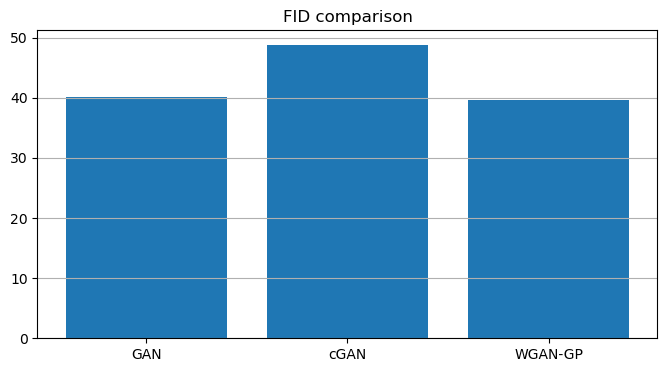

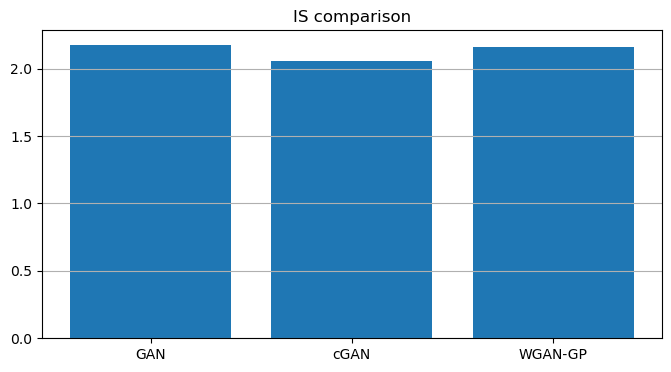

In [42]:
names = list(results.keys())
fids = [results[k]["FID"] for k in names]
iss = [results[k]["IS_mean"] for k in names]

plt.figure(figsize=(8, 4))
plt.bar(names, fids)
plt.title("FID comparison")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, iss)
plt.title("IS comparison")
plt.grid(True, axis="y")
plt.show()

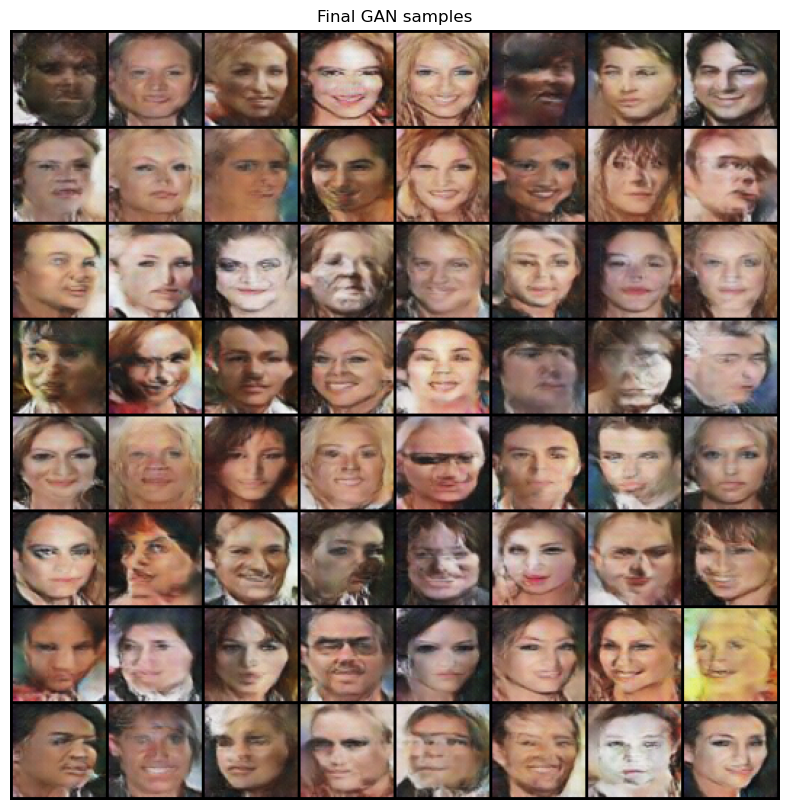

In [43]:
show_generated_images(G, z_dim=LATENT_DIM, n=64, title="Final GAN samples")

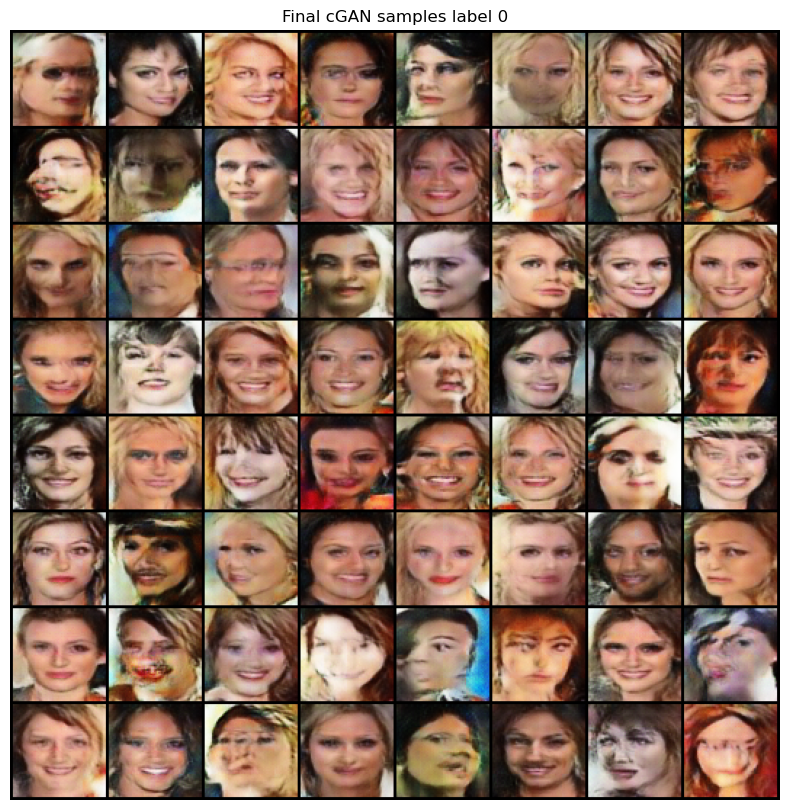

In [44]:
show_generated_images(cG, z_dim=LATENT_DIM, n=64, y=torch.zeros(64, dtype=torch.long), title="Final cGAN samples label 0")

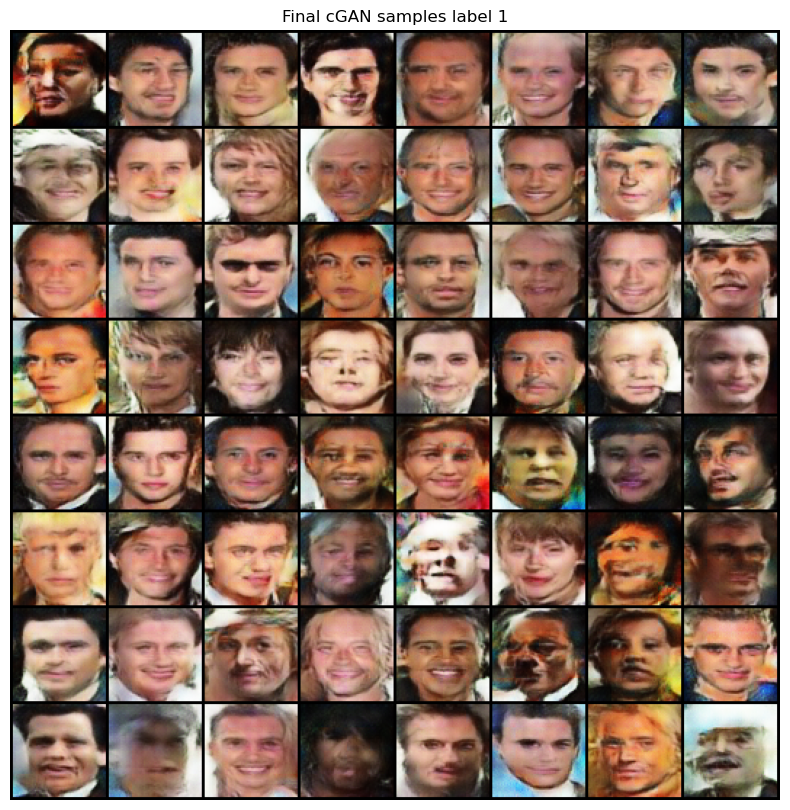

In [45]:
show_generated_images(cG, z_dim=LATENT_DIM, n=64, y=torch.ones(64, dtype=torch.long), title="Final cGAN samples label 1")

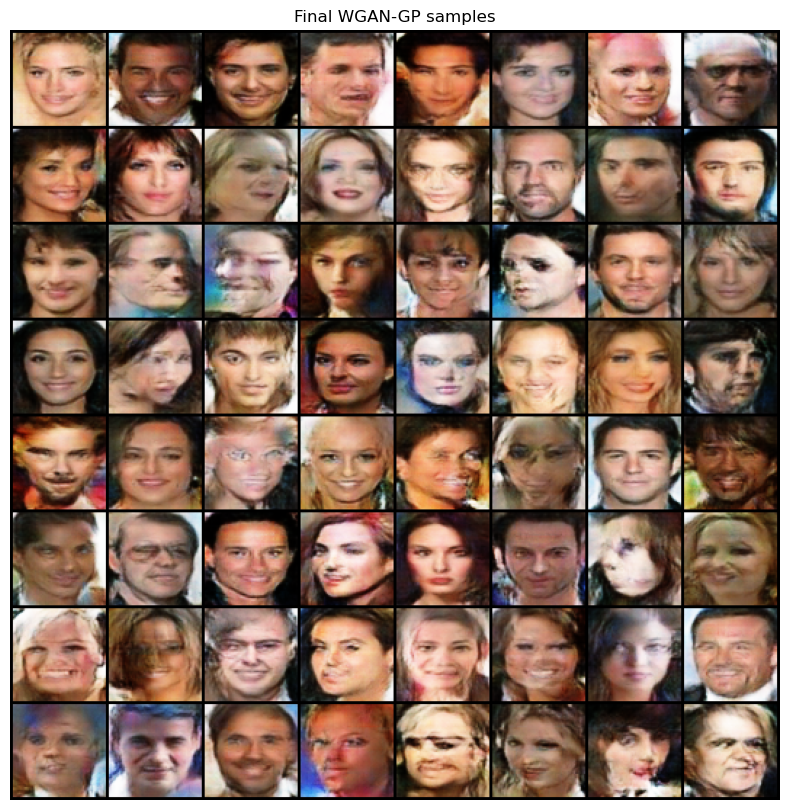

In [ ]:
show_generated_images(wG, z_dim=LATENT_DIM, n=64, title="Final WGAN-GP sample")